In [2]:
# ── Cell 0: Test Path ──────────────────────────────────────────

import glob
import os

# Define the path to the traffic data CSV files
data_path_new = r"..\..\traffic_data\new_format\*.csv"
all_files = glob.glob(data_path_new)
print(os.path.abspath(data_path_new)) 
print(f"find {len(all_files)} file in new format")

data_path_old = r"..\..\traffic_data\old_format\*.csv"
all_files_old = glob.glob(data_path_old)
print(os.path.abspath(data_path_old))
print(f"find {len(all_files_old)} file in old format")

e:\Study\Unitec\COMP8831_Machine_Learning\Assignment_4\code\traffic_data\new_format\*.csv
find 16 file in new format
e:\Study\Unitec\COMP8831_Machine_Learning\Assignment_4\code\traffic_data\old_format\*.csv
find 31 file in old format


In [3]:
# ── Cell 1: Read Dataset ──────────────────────────────────────────────

import pandas as pd
import glob
import os

# ── 1A: Read Old Format Data (2013 – 2019) ───────────────────────────
# Old format columns: class, siteRef, startDatetime, endDatetime, direction, count
# Note: 'class' column has BOM prefix (ï»¿class), use utf-8-sig encoding to remove it
# Old format uses string site IDs:
#   01N10433 → 2078 (SH1 Green Lane East Interchange Southbound)
#   01N20433 → 2079 (SH1 Green Lane East Interchange Northbound)

data_path_old = r"..\..\traffic_data\old_format\*.csv"
all_files_old = sorted(glob.glob(data_path_old))
print(f"Found {len(all_files_old)} old format files")

dfs_old = []  # List to store filtered old format DataFrames

for f in all_files_old:
    # utf-8-sig automatically removes BOM prefix from column names
    df_temp = pd.read_csv(f, encoding='utf-8-sig')
    
    # Filter using string site IDs (old format does not use numeric SITE_ALIAS)
    df_temp = df_temp[df_temp['siteRef'].isin(['01N10433', '01N20433'])]
    
    # Skip file if neither site is found
    if len(df_temp) == 0:
        print(f"✗ {os.path.basename(f)} — site not found, skipping")
        continue
    
    # Map string siteRef to numeric SITE_ALIAS to match new format
    df_temp['siteRef'] = df_temp['siteRef'].map({
        '01N10433': 2078,  # SH1 Green Lane East Interchange Southbound
        '01N20433': 2079   # SH1 Green Lane East Interchange Northbound
    })
    
    # Rename old format columns to match new format column names
    df_temp = df_temp.rename(columns={
        'startDatetime' : 'START_DATE',
        'siteRef'       : 'SITE_ALIAS',
        'direction'     : 'FLOW_DIRECTION',
        'count'         : 'TRAFFIC_COUNT',
        'class'         : 'CLASS_WEIGHT'
    })
    
    # Map L/H to Light/Heavy to match new format values
    df_temp['CLASS_WEIGHT'] = df_temp['CLASS_WEIGHT'].map({
        'L': 'Light',
        'H': 'Heavy'
    })
    
    # LANE_NUMBER is not available in old format, set to None
    df_temp['LANE_NUMBER'] = None
    
    # Keep only columns we need
    df_temp = df_temp[['START_DATE', 'SITE_ALIAS', 'LANE_NUMBER',
                        'FLOW_DIRECTION', 'CLASS_WEIGHT', 'TRAFFIC_COUNT']]
    
    dfs_old.append(df_temp)
    print(f"✓ {os.path.basename(f)} — rows after filtering: {len(df_temp)}")

df_old = pd.concat(dfs_old, ignore_index=True)
print(f"\nOld format merge complete! Total rows: {len(df_old)}")
print(df_old.head())

# ── 1B: Read New Format Data (Oct 2020 – Aug 2021) ───────────────────
# New format columns: START_DATE, SITE_ALIAS, REGION_NAME, SITE_REFERENCE,
#                     CLASS_WEIGHT, SITE_DESCRIPTION, LANE_NUMBER, FLOW_DIRECTION, TRAFFIC_COUNT

data_path_new = r"..\..\traffic_data\new_format\*.csv"
all_files_new = sorted(glob.glob(data_path_new))
print(f"\nFound {len(all_files_new)} new format files")

dfs_new = []  # List to store filtered new format DataFrames

for f in all_files_new:
    df_temp = pd.read_csv(f, encoding='latin-1')
    
    # Filter to keep only Site 2078 (Southbound) and 2079 (Northbound)
    df_temp = df_temp[df_temp['SITE_ALIAS'].isin([2078, 2079])]
    
    # Keep only columns we need for consistency with old format
    df_temp = df_temp[['START_DATE', 'SITE_ALIAS', 'LANE_NUMBER',
                        'FLOW_DIRECTION', 'CLASS_WEIGHT', 'TRAFFIC_COUNT']]
    
    dfs_new.append(df_temp)
    print(f"✓ {os.path.basename(f)} — rows after filtering: {len(df_temp)}")

df_new = pd.concat(dfs_new, ignore_index=True)
print(f"\nNew format merge complete! Total rows: {len(df_new)}")

# ── 1C: Combine Old and New Format Data ──────────────────────────────

# Convert START_DATE to datetime before concatenating
# This is faster than converting the entire combined dataset at once

# Old format date example: '21-FEB-2013 04:15'
df_old['START_DATE'] = pd.to_datetime(df_old['START_DATE'], format='%d-%b-%Y %H:%M', dayfirst=True)

# New format date example: '2020-10-01 00:30'
df_new['START_DATE'] = pd.to_datetime(df_new['START_DATE'], format='%Y-%m-%d %H:%M')

# Concatenate old and new format data
df = pd.concat([df_old, df_new], ignore_index=True)

# Sort by timestamp to ensure chronological order
df = df.sort_values('START_DATE').reset_index(drop=True)

# Keep only data up to Aug 2021 to exclude Delta lockdown period
# (New Zealand Delta lockdown started August 2021)
df = df[df['START_DATE'] < '2021-08-01']

print(f"\nFinal combined dataset:")
print(f"  Date range : {df['START_DATE'].min()} → {df['START_DATE'].max()}")
print(f"  Total rows : {len(df)}")
print(f"\nSample data:")
print(df.head())

Found 31 old format files
✓ 20130101_20130331_TMSTrafficQuarterHour.csv — rows after filtering: 34560
✓ 20130401_20130630_TMSTrafficQuarterHour.csv — rows after filtering: 33408
✓ 20130701_20130930_TMSTrafficQuarterHour.csv — rows after filtering: 29952
✓ 20131001_20131231_TMSTrafficQuarterHour.csv — rows after filtering: 21984
✓ 20140101_20140331_TMSTrafficQuarterHour.csv — rows after filtering: 15840
✓ 20140401_20140630_TMSTrafficQuarterHour.csv — rows after filtering: 16992
✓ 20140701_20140930_TMSTrafficQuarterHour.csv — rows after filtering: 16800
✓ 20141001_20141231_TMSTrafficQuarterHour.csv — rows after filtering: 16992
✓ 20150101_20150331_TMSTrafficQuarterHour.csv — rows after filtering: 16896
✓ 20150401_20150630_TMSTrafficQuarterHour.csv — rows after filtering: 17472
✓ 20150701_20150930_TMSTrafficQuarterHour.csv — rows after filtering: 17472
✓ 20151001_20151231_TMSTrafficQuarterHour.csv — rows after filtering: 28224
✓ 20160101_20160331_TMSTrafficQuarterHour.csv — rows after fil

In [4]:
# ── Cell 2: Basic Overview ──────────────────────────────────────────

# START_DATE already converted to datetime in Cell 1, no need to convert again

print("=== Basic Info ===")
print(f"Date range: {df['START_DATE'].min()} → {df['START_DATE'].max()}")
print(f"Total rows: {len(df)}")

# Site 2078 = SH1 Green Lane East Southbound (old: 01N10433)
# Site 2079 = SH1 Green Lane East Northbound (old: 01N20433)
print(f"\n=== Sites Count ===")
print(df['SITE_ALIAS'].value_counts())

# Both classes will be aggregated (summed) in a later step
print(f"\n=== Class Weight ===")
print(df['CLASS_WEIGHT'].value_counts())

# LANE_NUMBER is expected to have missing values (not available in old format)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())

# Helps detect outliers and understand the value range before normalisation
print(f"\n=== TRAFFIC_COUNT Stats ===")
print(df['TRAFFIC_COUNT'].describe())

=== Basic Info ===
Date range: 2013-01-01 00:00:00 → 2021-07-31 23:45:00
Total rows: 1279184

=== Sites Count ===
SITE_ALIAS
2078    640120
2079    639064
Name: count, dtype: int64

=== Class Weight ===
CLASS_WEIGHT
Light    707608
Heavy    571576
Name: count, dtype: int64

=== Missing Values ===
START_DATE             0
SITE_ALIAS             0
LANE_NUMBER       928976
FLOW_DIRECTION         0
CLASS_WEIGHT           0
TRAFFIC_COUNT          0
dtype: int64

=== TRAFFIC_COUNT Stats ===
count    1.279184e+06
mean     3.160059e+02
std      4.057707e+02
min      0.000000e+00
25%      2.100000e+01
50%      8.950000e+01
75%      4.915000e+02
max      2.647000e+03
Name: TRAFFIC_COUNT, dtype: float64


In [5]:
# ── Cell 3: Aggregate Light + Heavy vehicles and all lanes ────────────

# The raw data has separate rows for Light and Heavy vehicles at the same timestamp.
# Old format has no LANE_NUMBER, new format has multiple lanes.
# We group by START_DATE, SITE_ALIAS, FLOW_DIRECTION and sum TRAFFIC_COUNT
# to get total vehicle count per 15-min interval per site.

df_agg = df.groupby(
    ['START_DATE', 'SITE_ALIAS', 'FLOW_DIRECTION']
)['TRAFFIC_COUNT'].sum().reset_index()

print(f"Rows before aggregation: {len(df)}")
print(f"Rows after aggregation:  {len(df_agg)}")

# Verify each site has the expected number of timestamps
print(f"\nUnique timestamps per site:")
print(df_agg.groupby('SITE_ALIAS')['START_DATE'].nunique())

Rows before aggregation: 1279184
Rows after aggregation:  590872

Unique timestamps per site:
SITE_ALIAS
2078    295964
2079    294908
Name: START_DATE, dtype: int64


In [6]:
# ── Cell 4: Reindex and Fill Missing Timestamps ───────────────────────

# Debug analysis found that some timestamps are missing for each site:
#   Site 2078: 1344 missing timestamps (~14 days, sensor outage)
#   Site 2079:  288 missing timestamps (~3 days, sensor outage)
# These gaps are caused by sensor maintenance or equipment failure.
# We fill them using linear interpolation based on neighbouring values.

# Separate the two sites
df_2078 = df_agg[df_agg['SITE_ALIAS'] == 2078].set_index('START_DATE').sort_index()
df_2079 = df_agg[df_agg['SITE_ALIAS'] == 2079].set_index('START_DATE').sort_index()

# Create a complete 15-min time index from start to end
full_index = pd.date_range(
    start='2013-01-01 00:00',
    end='2021-07-31 23:45',
    freq='15min'
)
print(f"Expected total timestamps: {len(full_index)}")

# Reindex both sites to the full time index
# Missing timestamps will be filled with NaN first, then interpolated
df_2078 = df_2078['TRAFFIC_COUNT'].reindex(full_index)
df_2079 = df_2079['TRAFFIC_COUNT'].reindex(full_index)

# Use linear interpolation to fill missing values
# Linear interpolation estimates missing values based on neighbouring points
df_2078 = df_2078.interpolate(method='linear')
df_2079 = df_2079.interpolate(method='linear')

print(f"Site 2078 missing after interpolation: {df_2078.isnull().sum()}")
print(f"Site 2079 missing after interpolation: {df_2079.isnull().sum()}")
print(f"\nSite 2078 sample:")
print(df_2078.head(10))

Expected total timestamps: 300864
Site 2078 missing after interpolation: 0
Site 2079 missing after interpolation: 0

Site 2078 sample:
2013-01-01 00:00:00     287.0
2013-01-01 00:15:00    1085.0
2013-01-01 00:30:00     826.0
2013-01-01 00:45:00     630.0
2013-01-01 01:00:00     632.0
2013-01-01 01:15:00     900.0
2013-01-01 01:30:00     686.0
2013-01-01 01:45:00     627.0
2013-01-01 02:00:00     498.0
2013-01-01 02:15:00     423.0
Freq: 15min, Name: TRAFFIC_COUNT, dtype: float64


In [7]:
# ── Cell 5: Check Time Continuity ────────────────────────────────────

# After interpolation, verify that both sites have perfectly continuous 15-min intervals
# This is critical for LSTM/GRU models which rely on sequential time steps

def check_time_gaps(series, site_name):
    # Calculate time difference between consecutive timestamps
    time_diff = series.index.to_series().diff().dropna()
    expected = pd.Timedelta('15min')
    
    # Find any gaps that are not exactly 15 minutes
    gaps = time_diff[time_diff != expected]
    
    print(f"\n{site_name}:")
    print(f"  Total timestamps : {len(series)}")
    print(f"  Expected interval: 15 min")
    print(f"  Gaps found       : {len(gaps)}")
    print(f"  Start date       : {series.index.min()}")
    print(f"  End date         : {series.index.max()}")

check_time_gaps(df_2078, 'Site 2078 (Southbound)')
check_time_gaps(df_2079, 'Site 2079 (Northbound)')

print("\nTime continuity check complete!")


Site 2078 (Southbound):
  Total timestamps : 300864
  Expected interval: 15 min
  Gaps found       : 0
  Start date       : 2013-01-01 00:00:00
  End date         : 2021-07-31 23:45:00

Site 2079 (Northbound):
  Total timestamps : 300864
  Expected interval: 15 min
  Gaps found       : 0
  Start date       : 2013-01-01 00:00:00
  End date         : 2021-07-31 23:45:00

Time continuity check complete!


In [8]:
# ── Cell 6: Outlier Detection ─────────────────────────────────────────

# Use IQR (Interquartile Range) method to detect outliers in the final cleaned data
# IQR method:
#   lower_bound = Q1 - 1.5 * IQR  (abnormally low values)
#   upper_bound = Q3 + 1.5 * IQR  (abnormally high values)

def check_outliers(series, site_name):
    Q1 = series.quantile(0.25)   # 25% of values are below this
    Q3 = series.quantile(0.75)   # 75% of values are below this
    IQR = Q3 - Q1                # Spread of the middle 50% of data
    
    lower_bound = Q1 - 1.5 * IQR  # Values below this are abnormally low
    upper_bound = Q3 + 1.5 * IQR  # Values above this are abnormally high
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    print(f"\n{site_name}:")
    print(f"  Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  Normal range : {lower_bound:.1f} ~ {upper_bound:.1f}")
    print(f"  Outliers found: {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")
    print(f"  Max value    : {series.max():.1f}")
    print(f"  Min value    : {series.min():.1f}")

check_outliers(df_2078, 'Site 2078 (Southbound)')
check_outliers(df_2079, 'Site 2079 (Northbound)')


# ── Cell 6 continued: Fix the single outlier in Site 2079 ────────────

# The outlier at 2013-12-18 11:45 (value=2647) is likely a sensor recording error.
# Surrounding values are in the range 1259-1630, making 2647 implausible.
# We replace it with the average of the previous and next 15-min values.

outlier_timestamp = pd.Timestamp('2013-12-18 11:45:00')

# Calculate replacement value using neighbouring timestamps
prev_val = df_2079[outlier_timestamp - pd.Timedelta('15min')]  # 11:30 value
next_val = df_2079[outlier_timestamp + pd.Timedelta('15min')]  # 12:00 value
replacement = (prev_val + next_val) / 2

print(f"Original value : {df_2079[outlier_timestamp]:.1f}")
print(f"Previous value : {prev_val:.1f}")
print(f"Next value     : {next_val:.1f}")
print(f"Replacement    : {replacement:.1f}")

# Replace the outlier
df_2079[outlier_timestamp] = replacement
print(f"\nOutlier fixed! New value: {df_2079[outlier_timestamp]:.1f}")



Site 2078 (Southbound):
  Q1=227.0, Q3=1125.0, IQR=898.0
  Normal range : -1120.0 ~ 2472.0
  Outliers found: 0 (0.00%)
  Max value    : 1577.0
  Min value    : 0.0

Site 2079 (Northbound):
  Q1=177.0, Q3=1092.0, IQR=915.0
  Normal range : -1195.5 ~ 2464.5
  Outliers found: 1 (0.00%)
  Max value    : 2647.0
  Min value    : 0.0
Original value : 2647.0
Previous value : 1375.0
Next value     : 1630.0
Replacement    : 1502.5

Outlier fixed! New value: 1502.5


In [9]:
# ── Cell 7: Import Visualisation Libraries ────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent plot style for all figures
plt.rcParams['figure.figsize'] = (14, 5)  # Default figure size
plt.rcParams['font.size'] = 12            # Default font size
sns.set_theme(style='whitegrid')          # Clean white background with grid

print("Visualisation libraries ready!")

Visualisation libraries ready!


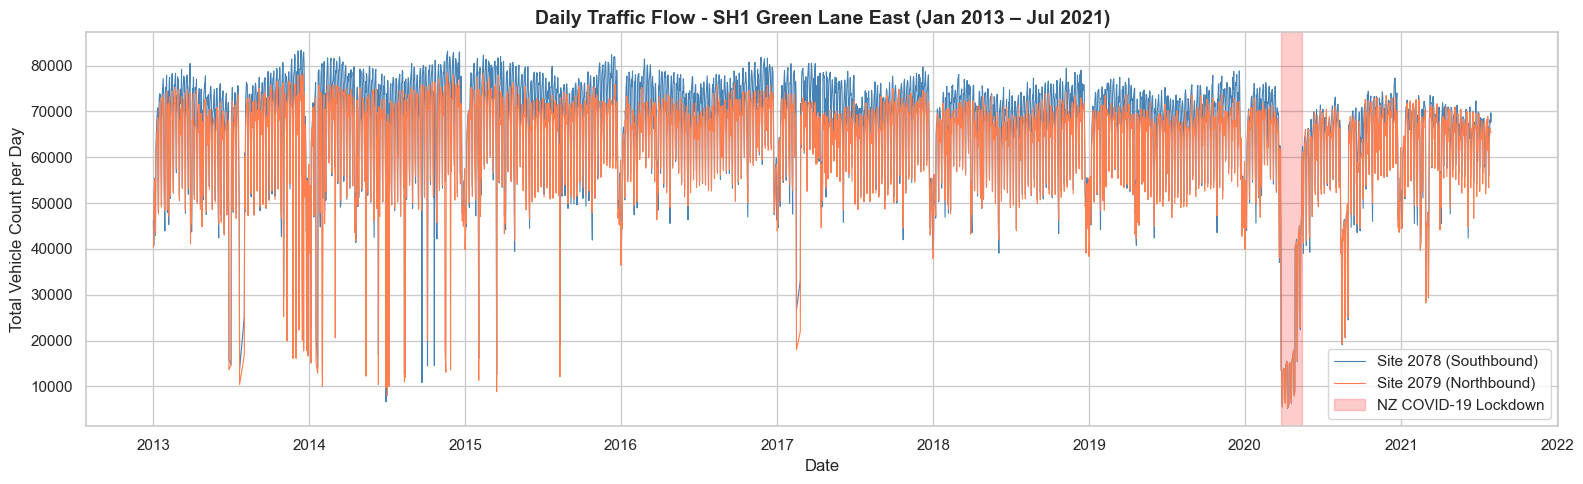

Figure saved to results/


In [10]:
# ── Cell 8: Overall Traffic Flow Trend ───────────────────────────────

# Resample 15-min data to daily totals for clearer long-term trend visualisation
# Daily resampling reduces noise while preserving seasonal and yearly patterns
df_2078_daily = df_2078.resample('D').sum()
df_2079_daily = df_2079.resample('D').sum()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_2078_daily.index, df_2078_daily.values,
        label='Site 2078 (Southbound)', color='steelblue', linewidth=0.8)
ax.plot(df_2079_daily.index, df_2079_daily.values,
        label='Site 2079 (Northbound)', color='coral', linewidth=0.8)

# Mark COVID-19 lockdown period in New Zealand (March - May 2020)
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-13'),
           alpha=0.2, color='red', label='NZ COVID-19 Lockdown')

ax.set_title('Daily Traffic Flow - SH1 Green Lane East (Jan 2013 – Jul 2021)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Vehicle Count per Day')
ax.legend()
plt.tight_layout()
plt.savefig('../results/01_overall_traffic_trend.png', dpi=150)
plt.show()
print("Figure saved to results/")

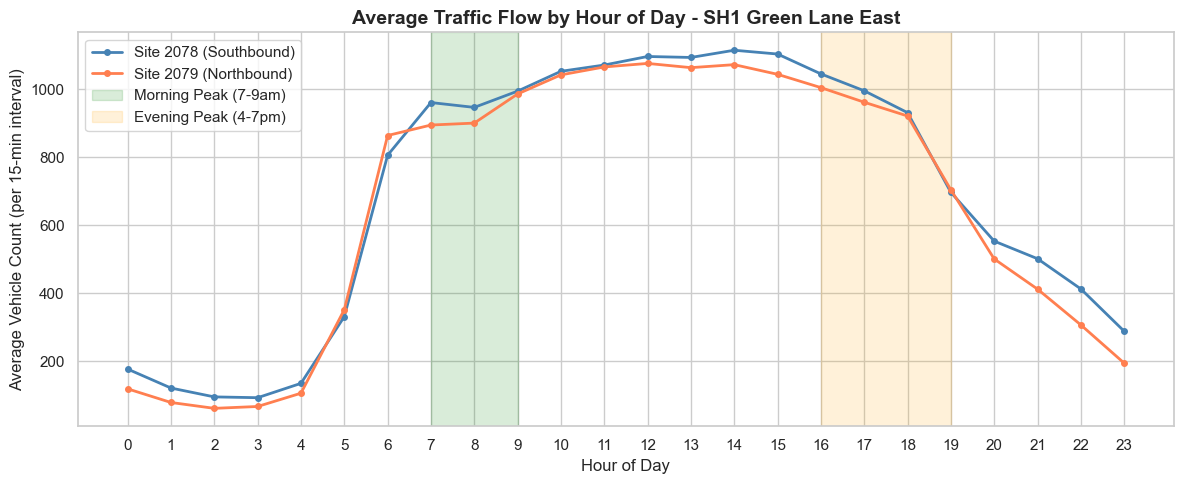

Figure saved to results/


In [11]:
# ── Cell 9: Average Traffic Flow by Hour of Day ───────────────────────

# Extract hour from timestamp to analyse intraday traffic patterns
# Average across all days to get a typical daily traffic profile
hourly_2078 = df_2078.groupby(df_2078.index.hour).mean()
hourly_2079 = df_2079.groupby(df_2079.index.hour).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_2078.index, hourly_2078.values,
        label='Site 2078 (Southbound)', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.plot(hourly_2079.index, hourly_2079.values,
        label='Site 2079 (Northbound)', color='coral', linewidth=2, marker='o', markersize=4)

# Highlight morning and evening peak hours typical for Auckland commuters
ax.axvspan(7, 9, alpha=0.15, color='green', label='Morning Peak (7-9am)')
ax.axvspan(16, 19, alpha=0.15, color='orange', label='Evening Peak (4-7pm)')

ax.set_title('Average Traffic Flow by Hour of Day - SH1 Green Lane East',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicle Count (per 15-min interval)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../results/02_hourly_pattern.png', dpi=150)
plt.show()
print("Figure saved to results/")

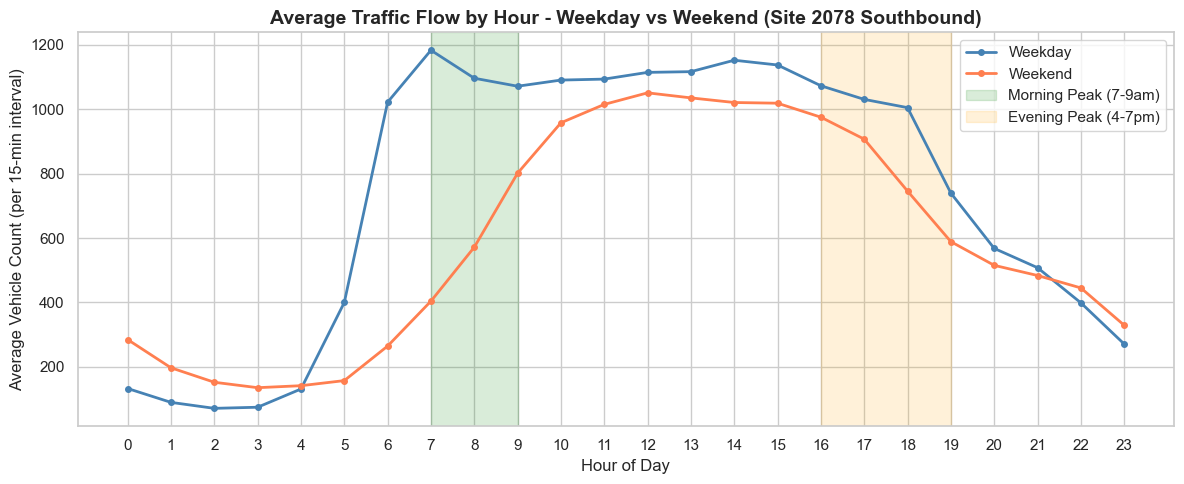

Figure saved to results/


In [12]:
# ── Cell 10: Hourly Pattern by Weekday vs Weekend (Site 2078)─────────────────────

# Add day of week to distinguish weekday and weekend patterns
# Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
df_2078_hour = df_2078.copy()
df_2078_hour = df_2078_hour.to_frame()
df_2078_hour['hour'] = df_2078_hour.index.hour
df_2078_hour['is_weekend'] = df_2078_hour.index.dayofweek >= 5  # 5=Saturday, 6=Sunday

# Separate weekday and weekend
weekday = df_2078_hour[df_2078_hour['is_weekend'] == False]
weekend = df_2078_hour[df_2078_hour['is_weekend'] == True]

hourly_weekday = weekday.groupby('hour')['TRAFFIC_COUNT'].mean()
hourly_weekend = weekend.groupby('hour')['TRAFFIC_COUNT'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_weekday.index, hourly_weekday.values,
        label='Weekday', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.plot(hourly_weekend.index, hourly_weekend.values,
        label='Weekend', color='coral', linewidth=2, marker='o', markersize=4)

# Mark morning and evening peak hours
ax.axvspan(7, 9, alpha=0.15, color='green', label='Morning Peak (7-9am)')
ax.axvspan(16, 19, alpha=0.15, color='orange', label='Evening Peak (4-7pm)')

ax.set_title('Average Traffic Flow by Hour - Weekday vs Weekend (Site 2078 Southbound)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicle Count (per 15-min interval)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../results/03_hourly_weekday_vs_weekend_2078.png', dpi=150)
plt.show()
print("Figure saved to results/")

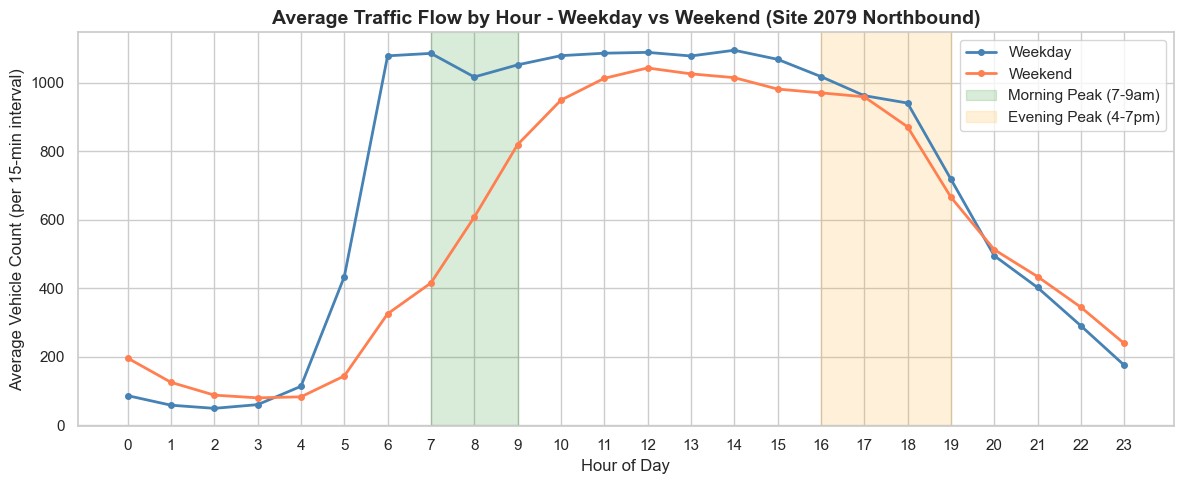

Figure saved to results/


In [13]:
# ── Cell 11: Hourly Pattern by Weekday vs Weekend (Site 2079) ─────────────────────

# Add day of week to distinguish weekday and weekend patterns
# Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
df_2079_hour = df_2079.copy()
df_2079_hour = df_2079_hour.to_frame()
df_2079_hour['hour'] = df_2079_hour.index.hour
df_2079_hour['is_weekend'] = df_2079_hour.index.dayofweek >= 5  # 5=Saturday, 6=Sunday

# Separate weekday and weekend
weekday = df_2079_hour[df_2079_hour['is_weekend'] == False]
weekend = df_2079_hour[df_2079_hour['is_weekend'] == True]

hourly_weekday = weekday.groupby('hour')['TRAFFIC_COUNT'].mean()
hourly_weekend = weekend.groupby('hour')['TRAFFIC_COUNT'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_weekday.index, hourly_weekday.values,
        label='Weekday', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.plot(hourly_weekend.index, hourly_weekend.values,
        label='Weekend', color='coral', linewidth=2, marker='o', markersize=4)

# Mark morning and evening peak hours
ax.axvspan(7, 9, alpha=0.15, color='green', label='Morning Peak (7-9am)')
ax.axvspan(16, 19, alpha=0.15, color='orange', label='Evening Peak (4-7pm)')

ax.set_title('Average Traffic Flow by Hour - Weekday vs Weekend (Site 2079 Northbound)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicle Count (per 15-min interval)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../results/03_hourly_weekday_vs_weekend_2079.png', dpi=150)
plt.show()
print("Figure saved to results/")

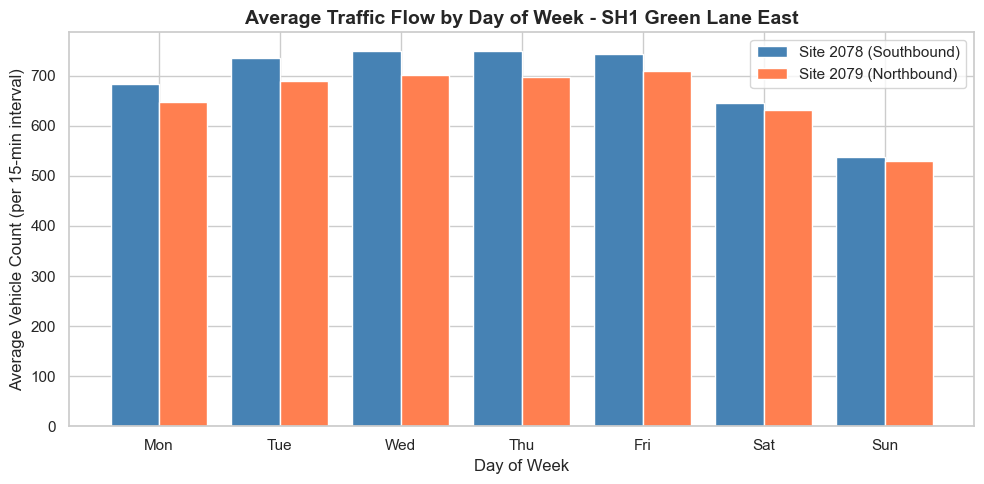

Figure saved to results/


In [14]:
# ── Cell 12: Average Traffic Flow by Day of Week ──────────────────────

# Day of week: Monday=0, Tuesday=1, ..., Sunday=6
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

daily_2078 = df_2078.groupby(df_2078.index.dayofweek).mean()
daily_2079 = df_2079.groupby(df_2079.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(7), daily_2078.values, width=0.4, 
       label='Site 2078 (Southbound)', color='steelblue', align='center')
ax.bar([x + 0.4 for x in range(7)], daily_2079.values, width=0.4,
       label='Site 2079 (Northbound)', color='coral', align='center')

ax.set_title('Average Traffic Flow by Day of Week - SH1 Green Lane East',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Vehicle Count (per 15-min interval)')
ax.set_xticks([x + 0.2 for x in range(7)])
ax.set_xticklabels(day_labels)
ax.legend()
plt.tight_layout()
plt.savefig('../results/04_weekly_pattern.png', dpi=150)
plt.show()
print("Figure saved to results/")

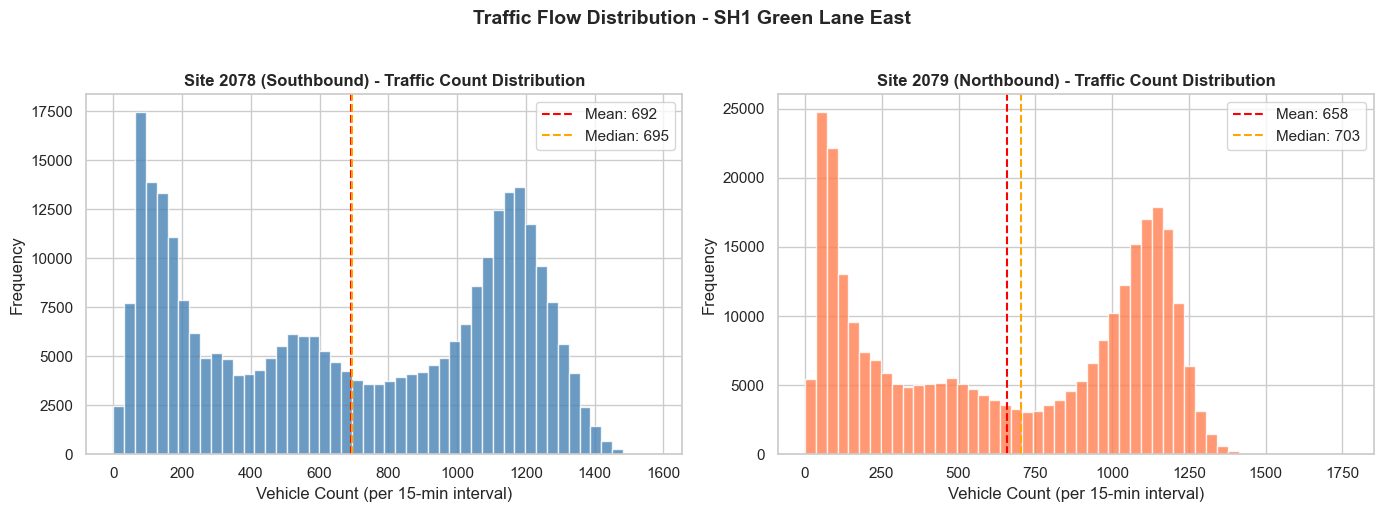

Figure saved to results/


In [15]:
# ── Cell 13: Traffic Flow Distribution ───────────────────────────────

# Plot the distribution of traffic count for both sites
# This helps understand the data spread and confirms no major skewness issues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Site 2078 distribution
axes[0].hist(df_2078.values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_2078.mean(), color='red', linestyle='--', 
                linewidth=1.5, label=f'Mean: {df_2078.mean():.0f}')
axes[0].axvline(df_2078.median(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Median: {df_2078.median():.0f}')
axes[0].set_title('Site 2078 (Southbound) - Traffic Count Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Vehicle Count (per 15-min interval)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Site 2079 distribution
axes[1].hist(df_2079.values, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(df_2079.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {df_2079.mean():.0f}')
axes[1].axvline(df_2079.median(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Median: {df_2079.median():.0f}')
axes[1].set_title('Site 2079 (Northbound) - Traffic Count Distribution',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vehicle Count (per 15-min interval)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Traffic Flow Distribution - SH1 Green Lane East',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/05_traffic_distribution.png', dpi=150)
plt.show()
print("Figure saved to results/")

In [16]:
# ── Cell 14: Save Cleaned Data to Disk ───────────────────────────────

# Save the cleaned time series to CSV files so preprocessing notebook
# can load them directly without re-running the entire EDA notebook

df_2078.to_csv('../data/cleaned_2078.csv', header=True)
df_2079.to_csv('../data/cleaned_2079.csv', header=True)

print("Cleaned data saved!")
print(f"  ../data/cleaned_2078.csv — {len(df_2078)} rows")
print(f"  ../data/cleaned_2079.csv — {len(df_2079)} rows")

Cleaned data saved!
  ../data/cleaned_2078.csv — 300864 rows
  ../data/cleaned_2079.csv — 300864 rows
